## Support vector classification

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [193]:
## lets create dataset
from sklearn.datasets import make_classification
x,y = make_classification(n_samples=1000, n_features=2 , n_classes=2 , n_clusters_per_class=2,n_redundant=0)

In [194]:
x

array([[-1.11442908,  0.18404388],
       [ 0.37649546, -1.26496628],
       [-1.23855764,  1.04108249],
       ...,
       [-0.27325385, -1.20747689],
       [-0.79179941, -1.04205356],
       [-0.74413596, -1.2047993 ]], shape=(1000, 2))

In [195]:
y

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,

<Axes: xlabel='0', ylabel='1'>

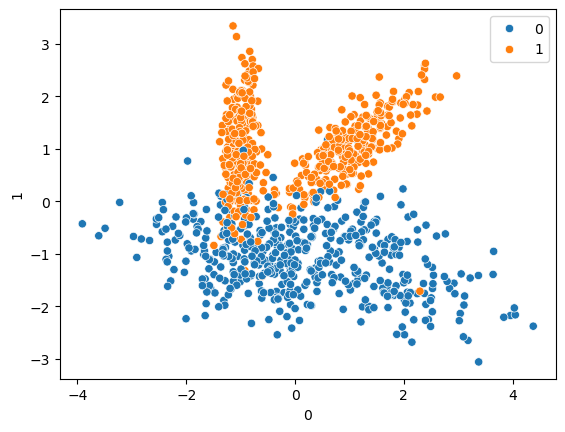

In [196]:
sns.scatterplot(x=pd.DataFrame(x)[0] , y=pd.DataFrame(x)[1] , hue=y)

In [197]:
# train test split
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , train_size=0.75 , random_state=10)

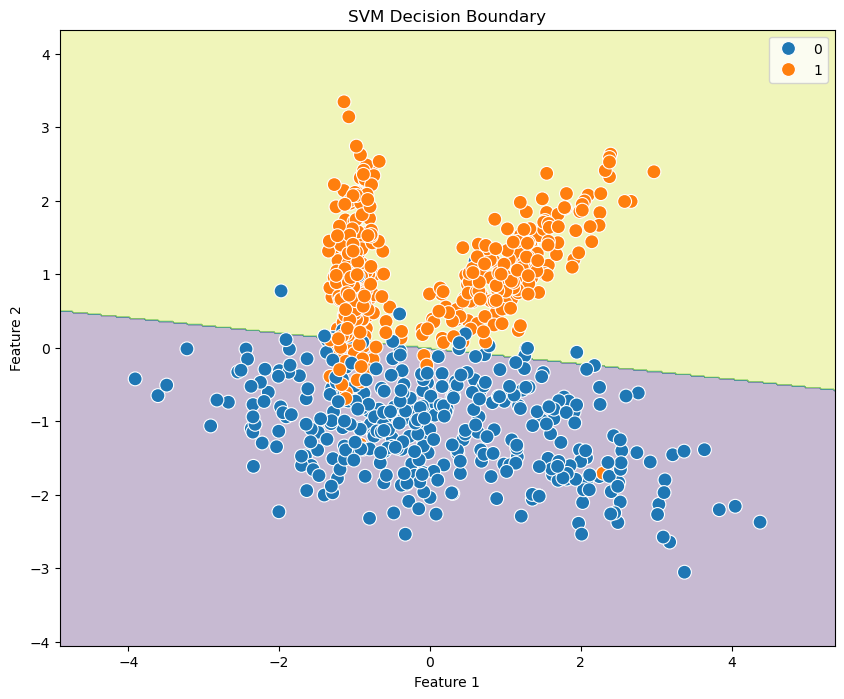

In [198]:
# Create mesh for decision boundary
h = 0.02  # step size in the mesh
x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary and data
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3)  # Decision boundary
sns.scatterplot(x=pd.DataFrame(x_train)[0], y=pd.DataFrame(x_train)[1], hue=y_train, s=100)
plt.title("SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

linerar kernel

In [199]:

from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(x_train , y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [200]:
y_pred = svc.predict(x_test)
print(len(y_pred))

250


In [201]:
# sns.scatterplot(x=pd.DataFrame(y_pred)[0], y=pd.DataFrame(y_test)[0] , hue=y_pred)

In [202]:
from sklearn.metrics import classification_report , confusion_matrix 
print(classification_report(y_test , y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       123
           1       0.94      0.92      0.93       127

    accuracy                           0.93       250
   macro avg       0.93      0.93      0.93       250
weighted avg       0.93      0.93      0.93       250



rbf kernel

In [203]:
rdf = SVC(kernel='rbf')
rdf.fit(x_train , y_train)
y_pred=rdf.predict(x_test)
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       123
           1       0.95      0.95      0.95       127

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

[[117   6]
 [  6 121]]


polynomial kernel


In [204]:
polynomial = SVC(kernel='poly')
polynomial.fit(x_train , y_train)
y_pred=polynomial.predict(x_test)
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       123
           1       0.92      0.95      0.94       127

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

[[113  10]
 [  6 121]]


sigmoid kernel

In [205]:
sigmoid = SVC(kernel="sigmoid")
sigmoid.fit(x_train , y_train)
y_pred=sigmoid.predict(x_test)
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       123
           1       0.90      0.87      0.88       127

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250

[[110  13]
 [ 16 111]]


Grid cross validation

hyperameter tunning

In [206]:
from  sklearn.model_selection import GridSearchCV

pram_grid = {'C':[0.1,1,10,100,1000],
             'gamma':[1,0.1,0.01,0.001,0.0001],
             'kernel':['rbf' , 'linear']}

In [207]:
grid = GridSearchCV(SVC() , param_grid=pram_grid , refit=True , cv=5 , verbose=3)

In [208]:
grid.fit(x_train , y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.953 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.953 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.933 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.920 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.947 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.940 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [209]:

y_pred=grid.predict(x_test)
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       123
           1       0.95      0.95      0.95       127

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

[[117   6]
 [  6 121]]


In [210]:
grid.best_params_

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}